Сделано с асгардархеей.

In [5]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.4 MB/s eta 0:00:00


Генерация фоновых последовательностей...
Расчет скоров...


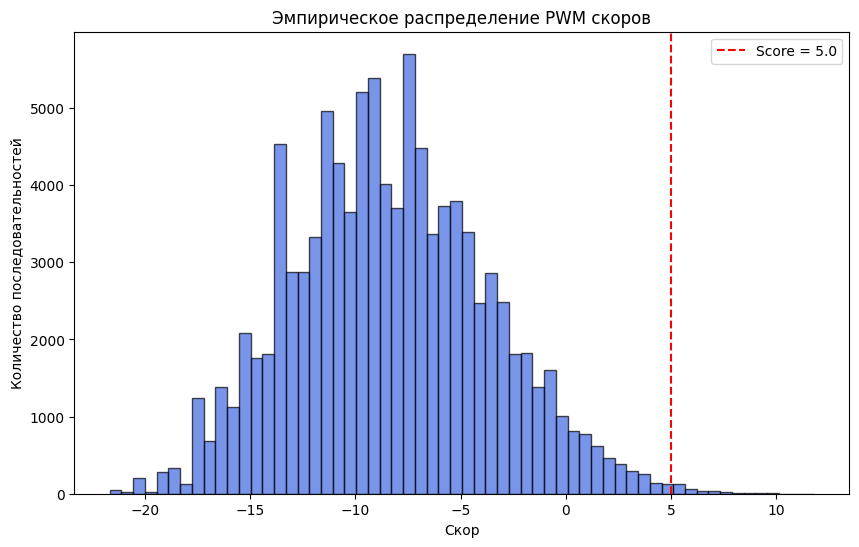

Порог (threshold) для p-value 10^-4: 9.0901
P-value для скора 5.0: 0.003560


In [9]:
import matplotlib.pyplot as plt


m = motifs.create([Seq(s) for s in sites])
pwm = m.counts.normalize(pseudocounts=0.5).log_odds()

def generate_random_seq(length=9):
    bases = ['A', 'C', 'G', 'T']
    probs = [0.295, 0.205, 0.205, 0.295]
    return "".join(np.random.choice(bases, p=probs) for _ in range(length))

print("Генерация фоновых последовательностей...")
background_seqs = [generate_random_seq(9) for _ in range(100000)]

print("Расчет скоров...")
scores = []
for s in background_seqs:
    score = pwm.calculate(Seq(s))
    scores.append(float(score))

scores = np.array(scores)

plt.figure(figsize=(10, 6))
plt.hist(scores, bins=60, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(x=5.0, color='red', linestyle='--', label='Score = 5.0')
plt.title("Эмпирическое распределение PWM скоров")
plt.xlabel("Скор")
plt.ylabel("Количество последовательностей")
plt.legend()
plt.show()

def get_pvalue(target_score):
    return np.mean(scores >= target_score)

threshold_10_4 = np.percentile(scores, 99.99)

print(f"Порог (threshold) для p-value 10^-4: {threshold_10_4:.4f}")
print(f"P-value для скора 5.0: {get_pvalue(5.0):.6f}")